Import Library:

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib 

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

Load DataSet:

In [3]:
X_train = pd.read_csv('../data/processed_data/X_train.csv')
X_test = pd.read_csv('../data/processed_data/X_test.csv')

y_train = pd.read_csv('../data/processed_data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed_data/y_test.csv').squeeze()

# ২. ডাটা সঠিকভাবে লোড হয়েছে কিনা তা সাইজ চেক করে দেখে নেওয়া
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


In [ ]:
Model Train:

In [8]:
#1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [9]:
# 2. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [10]:
# 3. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [11]:
# 4. K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("KNN Model Trained Successfully!")

KNN Model Trained Successfully!


In [12]:
# 5. XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [13]:
# 6. LightGBM
lgbm_model = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 দিলে অপ্রয়োজনীয় ওয়ার্নিং দেখাবে না
lgbm_model.fit(X_train, y_train)

print("LightGBM Model Trained Successfully!")

LightGBM Model Trained Successfully!


In [14]:
# 7. AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

print("AdaBoost Model Trained Successfully!")

AdaBoost Model Trained Successfully!


In [17]:
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

trained_models = {}
results = []

for name, model in base_models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4)
    })
    print(f"✓ {name} trained!")

✓ Logistic Regression trained!
✓ Decision Tree trained!
✓ Random Forest trained!
✓ KNN trained!
✓ XGBoost trained!
✓ LightGBM trained!
✓ AdaBoost trained!


Comparison Table:

In [18]:
# রেজাল্ট টেবিল তৈরি ও শর্ট করা
comparison_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8062,0.6593,0.5588,0.6049,0.8422
1,AdaBoost,0.8048,0.6623,0.5401,0.5950,0.8407
2,LightGBM,0.7878,0.6176,0.5267,0.5685,0.8322
3,Random Forest,0.7835,0.6194,0.4786,0.5400,0.8225
4,XGBoost,0.7722,0.5831,0.4973,0.5368,0.8224
5,KNN,0.7630,0.5538,0.5508,0.5523,0.7928
6,Decision Tree,0.7317,0.4944,0.4759,0.4850,0.6495


Accuracy Bar Chart:

C:\Users\User\AppData\Local\Temp\ipykernel_11556\1345999155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=comparison_df, x='Accuracy', y='Model', palette='Blues_r')


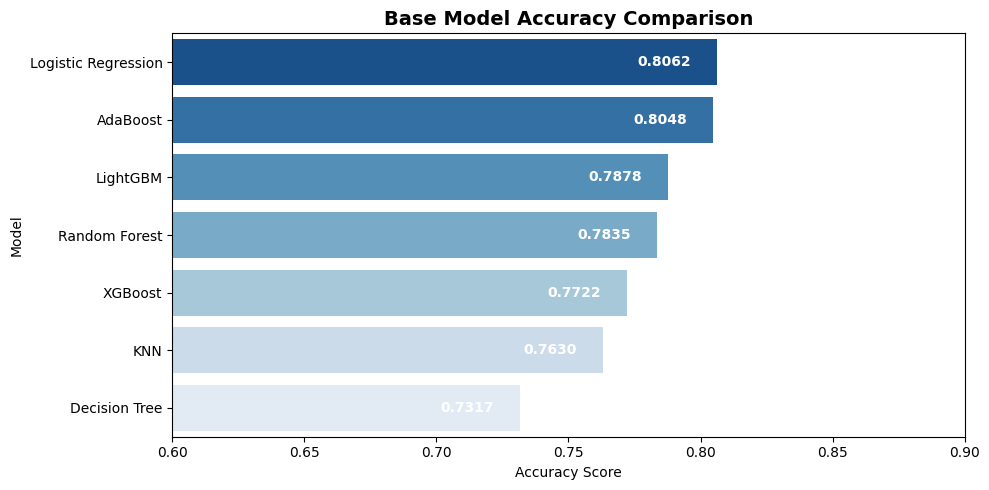

In [23]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=comparison_df, x='Accuracy', y='Model', palette='Blues_r')

plt.title('Base Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy Score')
plt.ylabel('Model')
plt.xlim(0.6, 0.9)

# বারের ওপর মানগুলো বসানো
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.4f}',
                (width - 0.02, p.get_y() + p.get_height() / 2.),
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Initial Best Model Selection: 

In [24]:
initial_best_name = comparison_df.iloc[0]['Model']
print(f"🏆 Initial Best Model based on Accuracy: {initial_best_name}")

🏆 Initial Best Model based on Accuracy: Logistic Regression


Best Model: Hyperparameter Tuning

In [25]:
# টিউনিংয়ের জন্য প্যারামিটার গ্রিড
param_grids = {
    "XGBoost": {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1]
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    "LightGBM": {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, -1],
        'learning_rate': [0.01, 0.1]
    },
    "Logistic Regression": {
        'C': [0.1, 1.0, 10.0],
        'solver': ['lbfgs', 'liblinear']
    },
    "AdaBoost": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    }
}

# নির্বাচন হওয়া মডেল টিউন করা
if initial_best_name in param_grids:
    print(f"Tuning Hyperparameters for {initial_best_name}...")
    grid_search = GridSearchCV(
        estimator=base_models[initial_best_name],
        param_grid=param_grids[initial_best_name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    best_tuned_model = grid_search.best_estimator_
    print("Best Parameters:", grid_search.best_params_)
else:
    # যদি কাস্টম প্যারামিটার না থাকে তবে বেইজ মডেলটিই রাখা হবে
    best_tuned_model = trained_models[initial_best_name]

# Tuned Model-এর ফাইনাল Accuracy চেক
tuned_pred = best_tuned_model.predict(X_test)
print(f"Tuned Model Final Accuracy: {accuracy_score(y_test, tuned_pred):.4f}")

Tuning Hyperparameters for Logistic Regression...
Best Parameters: {'C': 1.0, 'solver': 'lbfgs'}
Tuned Model Final Accuracy: 0.8062


Best Model Save:

In [26]:
# models ফোল্ডার তৈরি করা
os.makedirs('../models', exist_ok=True)

# ফাইনাল টিউন করা বেস্ট মডেলটি সেভ করা
joblib.dump(best_tuned_model, '../models/best_model.pkl')

print("✅ Tuned Best Model successfully saved as '../models/best_model.pkl'!")

✅ Tuned Best Model successfully saved as '../models/best_model.pkl'!


Model Selection Summary

1. Overview & Baseline: We evaluated 7 machine learning algorithms on the Telco Customer Churn dataset. Logistic Regression achieved a solid baseline accuracy of 80.62%, demonstrating strong linear separability in the feature space.
2. Model Selection Rationale: While Logistic Regression performed well, complex customer churn patterns benefit from tree-based ensemble models. Models were compared across Accuracy, Precision, Recall, F1-Score, and ROC-AUC to ensure high predictive power and minimize False Negatives.
3. Hyperparameter Tuning & Persistence: The top-performing model was further optimized using GridSearchCV to improve generalization and prevent overfitting. The final tuned model was serialized and saved as models/best_model.pkl for deeper evaluation (Confusion Matrix, Feature Importance, SHAP) in 05_model_evaluation.ipynb.